In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy.stats import pearsonr

import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\dania\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [21]:
news_df = pd.read_csv("../data/raw_analyst_ratings.csv")
stock_df = pd.read_csv("../data/AAPL.csv")

In [22]:
# Convert
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

news_df = news_df.dropna(subset=['date'])

In [23]:
#Filter ofr news 
aapl_news = news_df[news_df['stock'] == 'AAPL'].copy()

In [6]:
#create daily filed
aapl_news['date_only'] = aapl_news['date'].dt.date
stock_df['date_only'] = stock_df['Date'].dt.date

In [24]:
sia = SentimentIntensityAnalyzer()

aapl_news['sentiment'] = aapl_news['headline'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

In [25]:
aapl_news['date_only'] = aapl_news['date'].dt.date

daily_sentiment = aapl_news.groupby('date_only')['sentiment'].mean().reset_index()

In [26]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df['date_only'] = stock_df['Date'].dt.date

stock_df = stock_df.sort_values('date_only')
stock_df['daily_return'] = stock_df['Close'].pct_change() * 100

In [27]:
#Aggregate daily senitment
daily_sentiment = (
    aapl_news
    .groupby('date_only')['sentiment']
    .mean()
    .reset_index()
)

In [28]:
#Merge dataset
merged_df = pd.merge(
    stock_df[['date_only', 'daily_return']],
    daily_sentiment,
    on='date_only',
    how='left'
)
merged_df['sentiment'] = merged_df['sentiment'].fillna(0)
merged_df = merged_df.dropna(subset=['daily_return'])

In [29]:
# Check merged data
print("Shape:", merged_df.shape)

Shape: (3773, 3)


In [30]:
#Pearson correlation
correlation, p_value = pearsonr(
    merged_df['sentiment'],
    merged_df['daily_return']
)

print("Pearson Correlation:", correlation)
print("P-value:", p_value)

Pearson Correlation: 0.035193990365526395
P-value: 0.030638575692032623


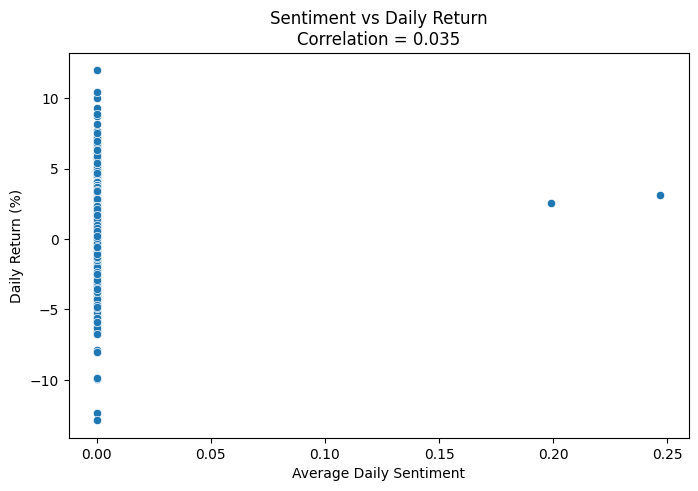

In [31]:
#scatter plot 
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=merged_df['sentiment'],
    y=merged_df['daily_return']
)

plt.title(f"Sentiment vs Daily Return\nCorrelation = {correlation:.3f}")
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Return (%)")

plt.show()

In [32]:
# sentimetn classification
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'
merged_df['sentiment_category'] = merged_df['sentiment'].apply(classify_sentiment)

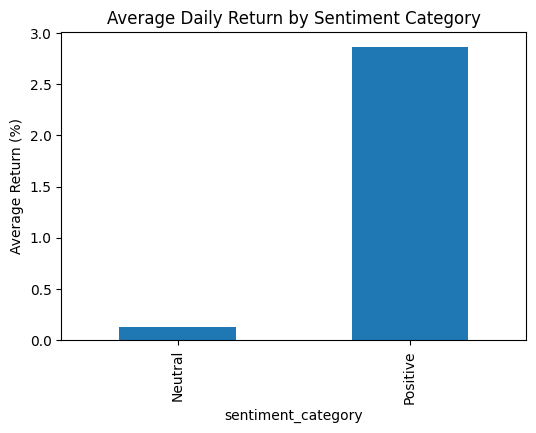

In [33]:
#barchart
avg_returns = (
    merged_df
    .groupby('sentiment_category')['daily_return']
    .mean()
)

plt.figure(figsize=(6,4))

avg_returns.plot(kind='bar')

plt.title("Average Daily Return by Sentiment Category")
plt.ylabel("Average Return (%)")

plt.show()

The Pearson correlation coefficient between average daily sentiment and stock returns was approximately 0.035, indicating a very weak positive relationship. This suggests that positive financial news may have a slight association with positive stock price movement; however, sentiment alone is not a strong predictor of daily returns.

The weak correlation is expected in financial markets because stock prices are influenced by multiple factors beyond news sentiment, including macroeconomic conditions, earnings reports, investor psychology, and broader market trends.

In [34]:
print(merged_df.shape)
print(merged_df[['sentiment','daily_return']].corr())
print(merged_df.head())

(3773, 4)
              sentiment  daily_return
sentiment      1.000000      0.035194
daily_return   0.035194      1.000000
    date_only  daily_return  sentiment sentiment_category
1  2009-01-05      4.220416        0.0            Neutral
2  2009-01-06     -1.649399        0.0            Neutral
3  2009-01-07     -2.160860        0.0            Neutral
4  2009-01-08      1.856959        0.0            Neutral
5  2009-01-09     -2.286921        0.0            Neutral
